In [1]:
# Cell 1: Imports and Environment Setup
import os
import pandas as pd
import matplotlib.pyplot as plt
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Define project root directory path
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(BASE_DIR, "data", "raw", "dataset-tickets-multi-lang3-4k.csv")

print(f"Project Base Directory: {BASE_DIR}")

Project Base Directory: e:\enterprise-rag-assistant


Total records loaded: 4000

Dataset Sample:


,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9
0,Problema crítico del servidor requiere atenció...,Es necesaria una investigación inmediata sobre...,Estamos investigando urgentemente el problema ...,Incident,Technical Support,high,es,IT Services,Urgent Issue,Service Disruption,Incident Report,Service Recovery,System Maintenance,NaN,NaN,NaN,NaN
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice,\n\nich hoffe, die...","Sehr geehrter <name>,\n\nvielen Dank, dass Sie...",Request,Customer Service,low,de,Tech Online Store,Sales Inquiry,Product Support,Customer Service,Order Issue,Returns and Exchanges,NaN,NaN,NaN,NaN
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es...","Prezado <name>,\n\nObrigado por entrar em cont...",Incident,Technical Support,high,pt,IT Services,Technical Support,Software Bug,Problem Resolution,Urgent Issue,IT Support,NaN,NaN,NaN,NaN


Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'business_type', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8', 'tag_9'],
      dtype='object')

Text Length Statistics:
count    4000.000000
mean      758.313750
std       495.517354
min         3.000000
25%       340.000000
50%       654.000000
75%      1118.250000
max      2843.000000
Name: text_length, dtype: float64


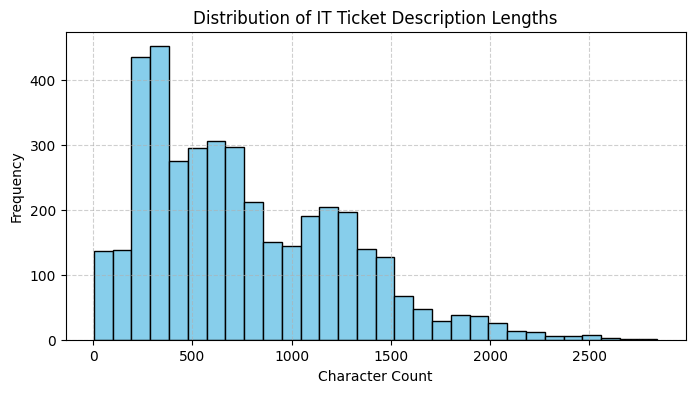

In [2]:
# Cell 2: Exploratory Data Analysis (EDA)
# Load IT support tickets dataset
df = pd.read_csv(data_path)
print(f"Total records loaded: {len(df)}")
print("\nDataset Sample:")
display(df.head(3))
print(df.columns)

# Analyze text length distribution
df['text_length'] = df['body'].astype(str).apply(len)
print("\nText Length Statistics:")
print(df['text_length'].describe())

# Plot text length distribution
plt.figure(figsize=(8, 4))
plt.hist(df['text_length'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of IT Ticket Description Lengths")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [3]:
# Cell 3: Chunking Experiments
# Compare different chunk sizes and overlaps
sample_text = df['body'].dropna().iloc[0]

text_splitter_small = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    length_function=len
)

text_splitter_medium = RecursiveCharacterTextSplitter(
    chunk_size=600,
    chunk_overlap=100,
    length_function=len
)

chunks_small = text_splitter_small.split_text(sample_text)
chunks_medium = text_splitter_medium.split_text(sample_text)

print(f"Original Text Length: {len(sample_text)} characters\n")
print(f"Small Chunks Count (300/50): {len(chunks_small)}")
print(f"Medium Chunks Count (600/100): {len(chunks_medium)}")

print("\n--- First Small Chunk Sample ---")
print(chunks_small[0] if chunks_small else "No chunk generated")

Original Text Length: 149 characters

Small Chunks Count (300/50): 1
Medium Chunks Count (600/100): 1

--- First Small Chunk Sample ---
Es necesaria una investigación inmediata sobre la interrupción en el servicio de gestión de AWS que está impactando funciones comerciales esenciales.
